# Frequency domain examples

Example code which computes eigenvalues and eigenvectors of linearized radial perturbations of perfect and Eckart fluid stars.

In [23]:
include("params.jl")

Star(3.0e15, 0.002227848581428124, 0.0007548154792386719, 700.0, 0.8, NeutronStarOscillations.var"#EOS_ε#2"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#EOS_p#3"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#dp_dε#4"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#d2p_dε2#5"{Float64, Float64}(700.0, 2.25), 0.1, 0.1, 10.0, 1.0, 5.0, 1.0, 7.548154792386719e-10, 7.54815479238672e-7, "./Results/Data/", "./Results/Figures/", 1.0e-15, 10, 100000000000, 1.0e-15, 1.0e-6, 1.0e-6, 200, 5, Main.xi_ID, Main.xi_dt_ID, Main.du_ID, Main.du_dr_ID, Main.du_dt_ID, Main.de_ID, Main.de_dr_ID, Main.de_dt_ID, 0.1, 0.1, 0.0005, 0.04, 50, 0.05, -1)

In [24]:
nPointsMatrix = 500;
h1_shoot = 4e-2;
h2_shoot = h1_shoot / 2;
h3_shoot = h1_shoot / 4;
h_TOV = 1e-5;

## Perfect fluid star in the cowling approximation

In [25]:
cowling = true;

In [26]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 13.450864 seconds (86.20 M allocations: 3.172 GiB, 34.09% gc time)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  8.923474 seconds (86.42 M allocations: 3.170 GiB, 10.44% gc time)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 10.582333 seconds (86.87 M allocations: 3.189 GiB, 15.31% gc time)


In [27]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [28]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [29]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [30]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [5.188233524964058, 8.691039581352696, 12.09328920306634, 15.452553782110227, 18.76485428757991]
(Med res) PF fluid frequencies (kHz): [5.188233546425662, 8.691039601599408, 12.093289226136825, 15.452553810225794, 18.764854323604414]
(High res) PF fluid frequencies (kHz): [5.188233547823963, 8.691039602847184, 12.093289227452507, 15.45255381168169, 18.76485432527268]


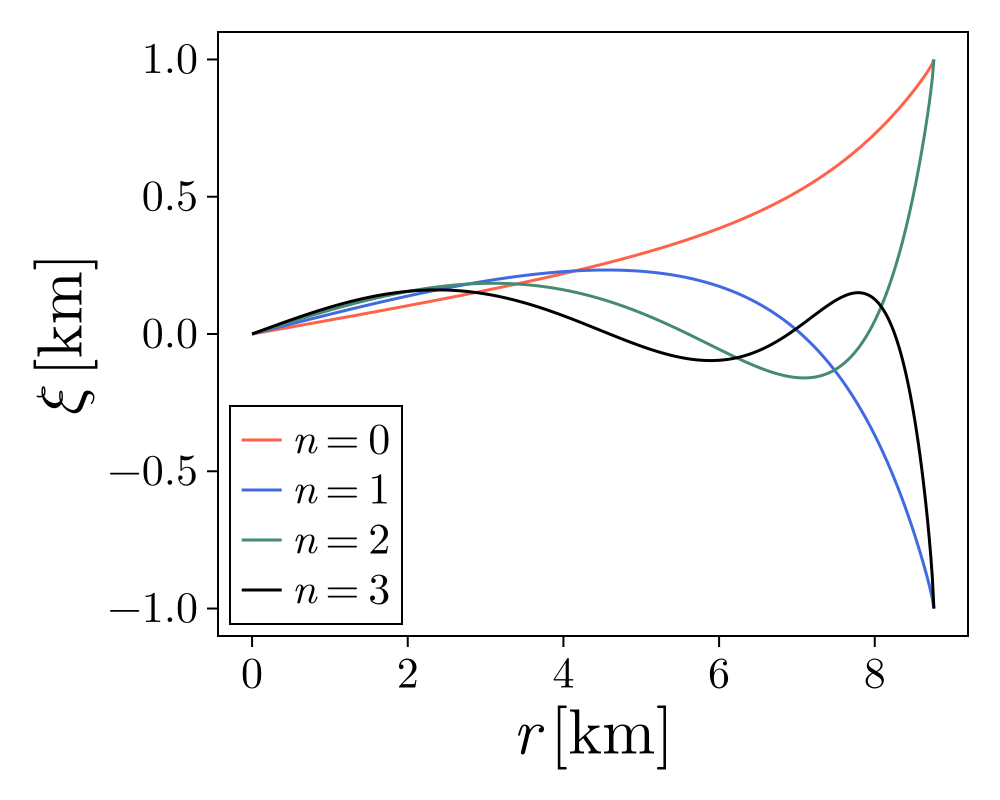

In [31]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot Cowling";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Perfect fluid star

In [32]:
cowling = false;

In [33]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  7.902195 seconds (86.21 M allocations: 3.170 GiB, 12.08% gc time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  8.928178 seconds (86.42 M allocations: 3.179 GiB, 17.60% gc time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  8.972896 seconds (86.87 M allocations: 3.181 GiB, 11.07% gc time)


In [34]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [35]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [36]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [37]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [2.1872180664767553, 7.474887383477031, 11.259756339868117, 14.815590482476455, 18.251969581340358]
(Med res) PF fluid frequencies (kHz): [2.1872180795696115, 7.4748873984113136, 11.259756359198105, 14.815590507332049, 18.251969614050797]
(High res) PF fluid frequencies (kHz): [2.1872180804476673, 7.474887399352327, 11.259756360323207, 14.815590508643696, 18.251969615592213]


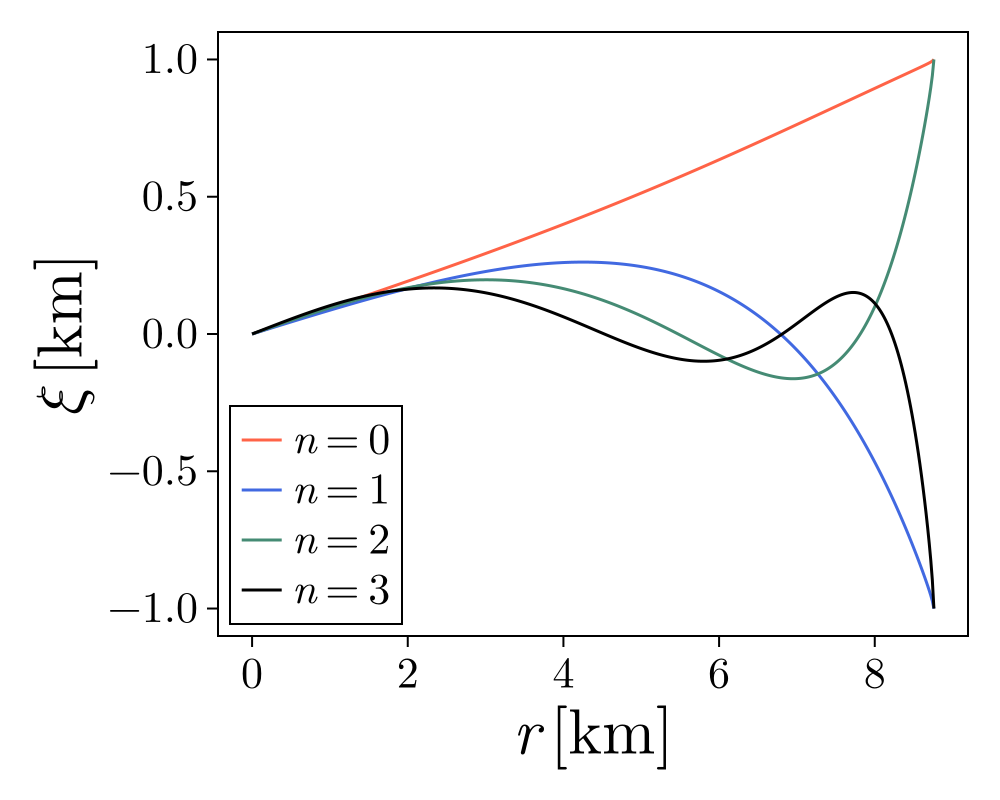

In [38]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Eckart star

In [39]:
cowling = false;

In [41]:
@time compute_eigensystem(Eckart_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 10.113913 seconds (86.23 M allocations: 3.184 GiB, 17.28% gc time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
  9.798949 seconds (86.47 M allocations: 3.203 GiB, 11.43% gc time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 10.602350 seconds (86.97 M allocations: 3.218 GiB, 15.22% gc time)


In [42]:
# load eigensystems. Eigenvalues are (complex-valued) linear frequencies, i.e., ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(Eckart_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(Eckart_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(Eckart_star, h3_shoot, cowling);


In [43]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [44]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) Eckart shooting method return codes: ", ret_1)
println("(Med res) Eckart shooting method return codes: ", ret_2)
println("(High res) Eckart shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) Eckart fluid frequencies (kHz): ", shooting_freqs_1)
println("(Med res) Eckart fluid frequencies (kHz): ", shooting_freqs_2)
println("(High res) Eckart fluid frequencies (kHz): ", shooting_freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) Eckart fluid frequencies (kHz): ComplexF64[2.1929920804311793 - 0.05583834513961146im, 7.50543628040967 - 0.27745079732026706im, 11.35426681951052 - 0.602723887417342im, 15.02238596970186 - 1.0402235341083834im, 18.63943986553766 - 1.5966605975433998im]
(Med res) Eckart fluid frequencies (kHz): ComplexF64[2.188004144248586 - 0.05569621613819848im, 7.479139458148217 - 0.2750391222594895im, 11.27682637153315 - 0.5923383137228674im, 14.863499705575004 - 1.012506999098098im, 18.3647352005432 - 1.5367408952332762im]
(High res) Eckart fluid frequencies (kHz): ComplexF64[2.18

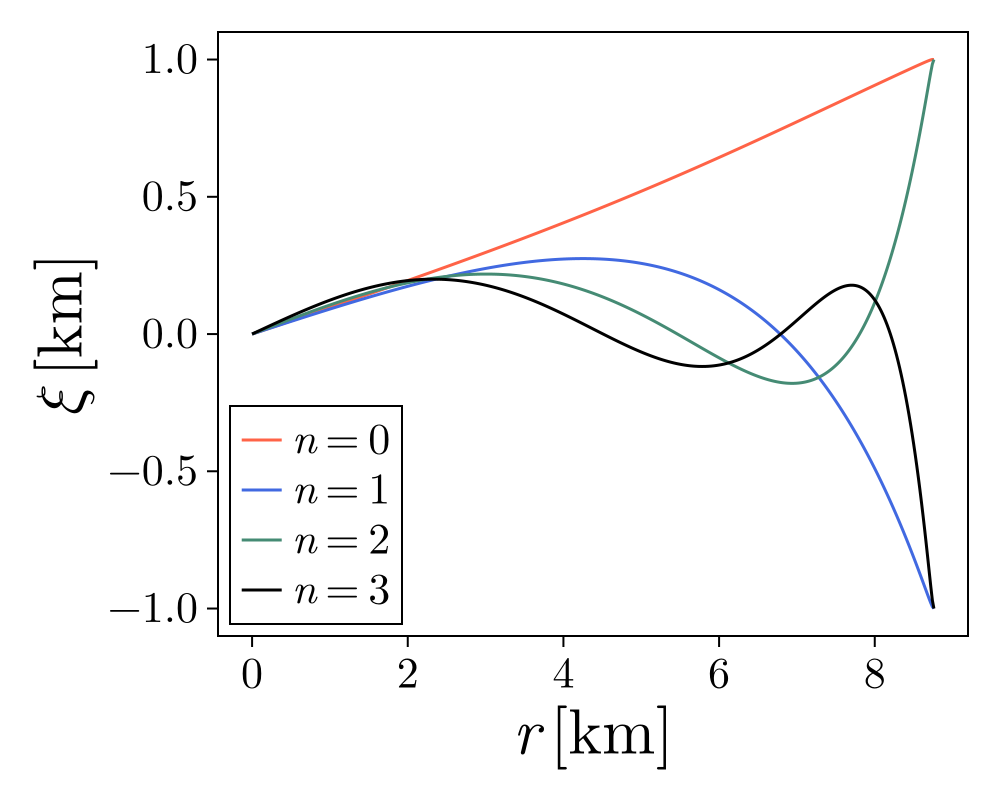

In [45]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, Eckart_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);